In [2]:
%pip install transformers opencv-python nltk sentencepiece

Note: you may need to restart the kernel to use updated packages.


In [3]:
from transformers import AutoProcessor as AP2, AutoModel
from transformers.image_utils import load_image
from PIL import Image
import matplotlib.patches as mpatches
import torch
import requests
import matplotlib.pyplot as plt
import cv2
import numpy as np
import torch.nn.functional as F

/opt/anaconda3/envs/ovseg/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
def get_device():
    """Select optimal device: MPS > CUDA > CPU"""
    if torch.backends.mps.is_available():
        device = torch.device("mps")
        print("Using MPS (Apple Silicon) device")
    elif torch.cuda.is_available():
        device = torch.device("cuda")
        print(f"Using CUDA device: {torch.cuda.get_device_name(0)}")
    else:
        device = torch.device("cpu")
        print("Using CPU device")
    return device

device = get_device()

Using MPS (Apple Silicon) device


In [5]:
processor = AP2.from_pretrained("google/siglip-base-patch16-224") 
model = AutoModel.from_pretrained("google/siglip-base-patch16-224").to(device).eval()
from ovs_eval.models.siglip import SiglipModel
siglip_model = SiglipModel(device=device)
# model_img_size = model.config.vision_config.image_size
# model_img_size
print("Processor image_processor.size:", processor.image_processor.size)
print("Model vision_config.image_size:", model.config.vision_config.image_size)
processor.image_processor.size = {"height": model.config.vision_config.image_size, "width": model.config.vision_config.image_size}

Processor image_processor.size: {'height': 224, 'width': 224}
Model vision_config.image_size: 224


In [6]:
import concurrent.futures
import os
from pycocotools.coco import COCO
import urllib.request
from pycocotools import mask as maskUtils
from nltk.corpus import wordnet

coco = COCO('annotations/instances_val2017.json')
img_ids = coco.getImgIds()

# Each annotation contains:
# {
#   'id': 123,
#   'image_id': 391895,
#   'category_id': 18,  # Object class (1-90)
#   'area': 27809.0,
#   'bbox': [x, y, width, height],
#   'segmentation': [...],  # RLE encoded mask or polygon points
#   'iscrowd': 0
# }


loading annotations into memory...
Done (t=0.28s)
creating index...
index created!


In [7]:
text_cats = ["dog", "person", "car", "bicycle", "cat", "chair", "table", "tree", "building", "sky"]

In [8]:
import requests
from nltk.corpus import wordnet
from functools import lru_cache
from __future__ import annotations


BABELNET_URL = "https://babelnet.io/v9/"
BABELNET_API_KEY = "3e365475-4b6a-4d8e-bb9f-f44b9b995fc3"

@lru_cache(maxsize=512)
def _babelnet_get_synset_id(word: str) -> str | None:
    """Step 1: Get the best BabelNet synset ID for an English word."""
    try:
        r = requests.get(
            f"{BABELNET_URL}getSynsetIds",
            params={"lemma": word, "searchLang": "EN", "key": BABELNET_API_KEY},
            timeout=8
        )
        if r.status_code != 200:
            return None
        data = r.json()
        # prefer WordNet-sourced synsets (most reliable for English)
        for item in data:
            if item.get("source") == "WN":
                return item["id"]
        # fallback to first result
        return data[0]["id"] if data else None
    except Exception:
        return None
    
@lru_cache(maxsize=512)
def _babelnet_get_synset_data(synset_id: str) -> dict:
    """Step 2: Get full synset data — lemmas, glosses, relations."""
    try:
        r = requests.get(
            f"{BABELNET_URL}getSynset",
            params={"id": synset_id, "targetLang": "EN", "key": BABELNET_API_KEY},
            timeout=8
        )
        if r.status_code != 200:
            return {}
        return r.json()
    except Exception:
        return {}
    
@lru_cache(maxsize=512)
def _babelnet_get_edges(synset_id: str) -> list[dict]:
    """Step 3: Get semantic edges (hypernyms, hyponyms) for a synset."""
    try:
        r = requests.get(
            f"{BABELNET_URL}getOutgoingEdges",
            params={"id": synset_id, "key": BABELNET_API_KEY},
            timeout=8
        )
        if r.status_code != 200:
            return []
        return r.json()
    except Exception:
        return []
    
def _babelnet_synonym(word: str) -> str | None:
    """Get a synonym from BabelNet — other English lemmas in the same synset."""
    synset_id = _babelnet_get_synset_id(word)
    if not synset_id:
        return None
    data = _babelnet_get_synset_data(synset_id)
    for sense in data.get("senses", []):
        lemma = sense.get("properties", {}).get("simpleLemma", "")
        lang  = sense.get("properties", {}).get("language", "")
        if lang == "EN" and lemma.lower() != word.lower() and "_" not in lemma:
            return lemma.lower().replace(" ", "_")
    return None


def _babelnet_hypernym(word: str) -> str | None:
    """
    Get hypernym via BabelNet edges.
    Relation pointer '+@' = hypernym in BabelNet/WordNet convention.
    """
    synset_id = _babelnet_get_synset_id(word)
    if not synset_id:
        return None
    edges = _babelnet_get_edges(synset_id)
    for edge in edges:
        # BabelNet uses pointer '+@' for hypernym (WordNet convention)
        if edge.get("pointer", {}).get("shortName") in ("+@", "is-a"):
            target_id = edge.get("target")
            if target_id:
                target_data = _babelnet_get_synset_data(target_id)
                for sense in target_data.get("senses", []):
                    lemma = sense.get("properties", {}).get("simpleLemma", "")
                    lang  = sense.get("properties", {}).get("language", "")
                    if lang == "EN" and lemma:
                        return lemma.lower().replace(" ", "_")
    return None


def _babelnet_hyponym(word: str) -> str | None:
    """
    Get hyponym via BabelNet edges.
    Relation pointer '+~' = hyponym in BabelNet/WordNet convention.
    """
    synset_id = _babelnet_get_synset_id(word)
    if not synset_id:
        return None
    edges = _babelnet_get_edges(synset_id)
    for edge in edges:
        if edge.get("pointer", {}).get("shortName") in ("+~", "has-kind"):
            target_id = edge.get("target")
            if target_id:
                target_data = _babelnet_get_synset_data(target_id)
                for sense in target_data.get("senses", []):
                    lemma = sense.get("properties", {}).get("simpleLemma", "")
                    lang  = sense.get("properties", {}).get("language", "")
                    if lang == "EN" and lemma:
                        return lemma.lower().replace(" ", "_")
    return None



In [38]:
from matplotlib.pyplot import axes
from collections import defaultdict


def get_class_name(coco, category_id):
    cat_info = coco.loadCats(category_id)[0]
    return cat_info['name']

def get_annotations_for_image(image_ids, coco):
    ann_ids = coco.getAnnIds(imgIds=image_ids)
    annotations = coco.loadAnns(ann_ids)
    return annotations

def get_objects_from_annotations(annotations, coco):
    ground_truth_objects = []
    img_ids_per_cat = defaultdict(list)
    for ann in annotations:
        category_id = ann['category_id']
        class_name = get_class_name(coco, category_id)
        ground_truth_objects.append(class_name)
        img_ids_per_cat[category_id].append(ann['image_id'])
    return ground_truth_objects, img_ids_per_cat

def get_img(image_id, coco):
    img_meta = coco.loadImgs(image_id)[0]
    url = img_meta['coco_url']
    image = load_image(url)
    return image

def visualize_segmentation_with_labels(image, annotations, text_cats, coco, model, processor, threshold = 0.5, desc = False):
    """
    Visualize segmentation masks with class labels on the image.
    """
    gt_masks = {}
    pred_masks = {}
    # Convert PIL image to numpy array
    if hasattr(image, 'convert'):
        img_array = np.array(image.convert('RGB'))
    else:
        img_array = image
    
    h, w = img_array.shape[:2]
    gt_overlay = img_array.copy().astype(float)
    
    colors = {}
    label_positions = []
    
    for ann in annotations:
        cat_id = ann['category_id']
        class_name = get_class_name(coco, cat_id)
        
        # Generate unique color per category
        if cat_id not in colors:
            colors[cat_id] = np.random.randint(50, 255, 3)
        
        # Decode segmentation mask
        if isinstance(ann['segmentation'], list):
            from pycocotools.mask import frPyObjects
            rle = frPyObjects(ann['segmentation'], h, w)
            mask = maskUtils.decode(rle)
            if isinstance(mask, np.ndarray) and len(mask.shape) == 3:
                mask = np.any(mask, axis=2)
        else:
            mask = maskUtils.decode(ann['segmentation'])

        if cat_id not in gt_masks:
            gt_masks[cat_id] = mask
        else:
            gt_masks[cat_id] = np.logical_or(gt_masks[cat_id], mask)
        
        color = colors[cat_id]
        
        # Apply color overlay
        gt_overlay[mask == 1] = gt_overlay[mask == 1] * 0.5 + np.array(color) * 0.5
        
        # Get centroid for label placement
        y_indices, x_indices = np.where(mask == 1)
        if len(y_indices) > 0:
            centroid_x = int(np.mean(x_indices))
            centroid_y = int(np.mean(y_indices))
            label_positions.append({
                'class_name': class_name,
                'centroid': (centroid_x, centroid_y),
                'color': color
            })
    
    gt_overlay = gt_overlay.astype(np.uint8)
    
    # Create figure
    fig, axes = plt.subplots(1, 3, figsize=(16, 8))
    
    axes[0].imshow(img_array)
    axes[0].set_title('Original Image')
    axes[0].axis('off')
    
    axes[1].imshow(gt_overlay)
    
    # Draw text labels with background
    for label_info in label_positions:
        x, y = label_info['centroid']
        text = label_info['class_name']
        
        # Draw text with background box
        axes[1].text(x, y, text, fontsize=10, color='white',
                bbox=dict(boxstyle='round,pad=0.5', 
                         facecolor='black', alpha=0.7, edgecolor='white'),
                ha='center', va='center', weight='bold')
    
    axes[1].set_title('Segmentation with Ground Truth Labels', fontsize=14)
    axes[1].axis('off')

    pred_overlay = img_array.copy().astype(float)
    pred_colors = plt.cm.tab20(np.linspace(0, 1, len(text_cats)))
    original_height, original_width = img_array.shape[:2]

    for idx, (p_base, p_var) in enumerate(text_cats.items()):
        text_prompt = p_var if desc else f"a photo of a {p_var}"
        
        inputs = processor(
            text=text_prompt, images=image, return_tensors="pt", padding=True
        ).to(device)

        with torch.inference_mode():
            outputs = model(**inputs)

        cat_id = coco.getCatIds(catNms=[p_base])[0]
        
        # Get image-level logits
        if hasattr(outputs, 'logits_per_image'):
            logits = outputs.logits_per_image[0, 0].cpu().item()
        else:
            logits = outputs.logits[0, 0].cpu().item()
        
        # Convert to probability
        prob = float(torch.sigmoid(torch.tensor(logits)).numpy())
        
        # Broadcast to image
        mask = np.ones((original_height, original_width), dtype=np.float32) * prob
        pred_masks[cat_id] = mask
        if mask.sum() > 0:
            pred_color = (np.array(pred_colors[idx][:3]) * 255).astype(np.uint8)
            pred_overlay[mask.cpu().numpy() == 1] = pred_overlay[mask.cpu().numpy() == 1] * 0.4 + np.array(pred_color) * 0.6
            mask_np = mask.cpu().numpy() == 1
            # Find centroid of mask for label placement
            y_indices, x_indices = np.where(mask_np)
            if len(y_indices) > 0:
                centroid_x = int(np.mean(x_indices))
                centroid_y = int(np.mean(y_indices))
                
                # Add label at centroid
                axes[2].text(centroid_x, centroid_y, p_var, 
                            fontsize=10, color='white', weight='bold',
                            bbox=dict(boxstyle='round,pad=0.5', 
                                    facecolor='black', alpha=0.7, edgecolor='white'),
                            ha='center', va='center')

    axes[2].imshow(pred_overlay.astype(np.uint8))
    axes[2].set_title('Segmentation Overlay', fontsize=14, weight='bold')
    axes[2].axis('off')

    plt.tight_layout()
    
    return fig, gt_overlay, pred_overlay, gt_masks, pred_masks

def get_segmentation_masks(image, annotations, text_cats, coco, model, processor, threshold = 0.5, desc = False):
    """
    Visualize segmentation masks with class labels on the image.
    """
    gt_masks = {}
    pred_masks = {}
    # Convert PIL image to numpy array
    if hasattr(image, 'convert'):
        img_array = np.array(image.convert('RGB'))
    else:
        img_array = image
    
    h, w = img_array.shape[:2]
    
    colors = {}
    
    for ann in annotations:
        cat_id = ann['category_id']
        
        # Generate unique color per category
        if cat_id not in colors:
            colors[cat_id] = np.random.randint(50, 255, 3)
        
        # Decode segmentation mask
        if isinstance(ann['segmentation'], list):
            if len(ann['segmentation']) == 0:
                mask = np.zeros((h, w), dtype=np.uint8)
            elif isinstance(ann['segmentation'][0], dict):
                mask = maskUtils.decode(ann['segmentation'])
            else:
                from pycocotools.mask import frPyObjects
                rle = frPyObjects(ann['segmentation'], h, w)
                mask = maskUtils.decode(rle)
        elif isinstance(ann['segmentation'], dict):
            # mask = maskUtils.decode(ann['segmentation'])
            if isinstance(ann['segmentation']['counts'], list):
                from pycocotools.mask import frPyObjects
                rle = frPyObjects([ann['segmentation']], h, w)
                mask = maskUtils.decode(rle)
            else:
                # Already in bytes format
                mask = maskUtils.decode(ann['segmentation'])
        else:
            mask = np.zeros((h, w), dtype=np.uint8)

        if isinstance(mask, np.ndarray) and len(mask.shape) == 3:
            mask = np.any(mask, axis=2).astype(np.uint8)

        if cat_id not in gt_masks:
            gt_masks[cat_id] = mask
        else:
            gt_masks[cat_id] = np.logical_or(gt_masks[cat_id], mask)
        
    original_height, original_width = img_array.shape[:2]

    if hasattr(model, 'predict'):
        pred_masks = model.predict(image, text_cats, coco, threshold=threshold, desc=desc)
    else:
        for idx, (p_base, p_var) in enumerate(text_cats.items()):
            text_prompt = p_var if desc else f"a photo of a {p_var}"
            
            inputs = processor(
                text=text_prompt, images=image, return_tensors="pt", padding=True
            ).to(device)
            # print(f"Input pixel values shape: {inputs['pixel_values'].shape}")

            with torch.inference_mode():
                outputs = model(**inputs)

            cat_id = coco.getCatIds(catNms=[p_base])[0]

            # get text embedding (from text encoder's [CLS] token)
            text_features = outputs.text_model_output.last_hidden_state[:, 0, :]
            text_features = F.normalize(text_features, dim=-1)

            vision_features = outputs.vision_model_output.last_hidden_state
            batch_size, num_patches, hidden_dim = vision_features.shape
            patch_size = int(np.sqrt(num_patches))
            # Reshape to (batch, patch_size, patch_size, hidden_dim)
            vision_features = vision_features.reshape(
                batch_size, patch_size, patch_size, hidden_dim
            )
            # Normalize vision features
            vision_features = F.normalize(vision_features, dim=-1)

            # Compute similarity between each patch and text
            similarity_map = torch.einsum(
                'bpqd,bd->bpq',
                vision_features,
                text_features
            )

            probs = torch.sigmoid(similarity_map)[0]
            mask = (probs > threshold).float().unsqueeze(0).unsqueeze(0)
            mask = F.interpolate(mask, size=(original_height, original_width), mode='bilinear', align_corners=False)
            mask = mask.squeeze(0).squeeze(0)
            pred_masks[cat_id] = mask.cpu().numpy()
    
    return gt_masks, pred_masks


def calculate_miou(gt_masks, pred_masks):
    """
    Calculate mean Intersection over Union (mIoU).
    
    Args:
        gt_masks: Dictionary mapping class_id to ground truth binary mask
        pred_masks: Dictionary mapping class_id to predicted binary mask
        num_classes: Total number of classes
    
    Returns:
        miou: Mean IoU across all classes
        ious: Dictionary of per-class IoU values
    """
    ious = {}
    
    for class_id in pred_masks.keys():
        gt_mask = gt_masks.get(class_id, np.zeros_like(list(gt_masks.values())[0]) if gt_masks else None)
        pred_mask = pred_masks.get(class_id, np.zeros_like(list(pred_masks.values())[0]) if pred_masks else None)
        
        if gt_mask is None or pred_mask is None:
            continue
        
        # Convert to binary
        gt_binary = (gt_mask > 0).astype(np.uint8)
        pred_binary = (pred_mask > 0).astype(np.uint8)
        
        # Calculate intersection and union
        intersection = np.logical_and(gt_binary, pred_binary).sum()
        union = np.logical_and(gt_binary, pred_binary).sum() + np.logical_xor(gt_binary, pred_binary).sum()
        
        # Avoid division by zero
        if union == 0:
            iou = 0.0
        else:
            iou = intersection / union
        
        ious[class_id] = iou
    
    # Calculate mean IoU
    miou = np.mean(list(ious.values())) if ious else 0.0
    
    return miou, ious

def get_syn(word):
    synsets = wordnet.synsets(word)
    if synsets:
        return synsets[0].lemma_names()[0]
    return word

def get_linguistic_cats(cats):
    orig_cats, syn_cats, hyper_cats, hypo_cats = {}, {}, {}, {}
    for cat in cats:
        synset = wordnet.synsets(cat)[0] if wordnet.synsets(cat) else None
        if synset:
            synonym = next((lemma.name() for lemma in synset.lemmas() if lemma.name() != cat), cat)
            # print(f"WuP simarity between '{cat}' and synonym '{synonym}': {synset.wup_similarity(synonym)}")
            hypernyms = synset.hypernyms()
            hypernym = next((lemma.name() for lemma in hypernyms[0].lemmas()), cat) if hypernyms else cat
            hyponyms = synset.hyponyms()
            hyponym = next((lemma.name() for lemma in hyponyms[0].lemmas()), cat) if hyponyms else cat
        else:
            synonym = cat
            hypernym = cat
            hyponym = cat
        orig_cats[cat] = cat
        syn_cats[cat] = synonym
        hyper_cats[cat] = hypernym
        hypo_cats[cat] = hyponym

    return orig_cats, syn_cats, hyper_cats, hypo_cats

def get_linguistic_cats_v2(cats):
    orig_cats, syn_cats, hyper_cats, hypo_cats = {}, {}, {}, {}
    for cat in cats:
        orig_cats[cat] = cat
        synset = wordnet.synsets(cat)[0] if wordnet.synsets(cat) else None
        # manual = COCO_MANUAL.get(cat, COCO_MANUAL.get(cat.replace("_", " "), None))
        synonym, synonym_bblNet = None, None
        if synset:
            synonym = next((l.name() for l in synset.lemmas() if l.name().lower() != cat.lower()),None)
        if synonym is None:
            synonym_bblNet = _babelnet_synonym(cat)
        syn_cats[cat] = synonym if synonym is not None else synonym_bblNet
        # print(f"Category: {cat}, Synonym (WordNet): {synonym}, Synonym (BabelNet): {synonym_bblNet}")

        hypernym, hypernym_bblNet = None, None
        if synset:                                                      # 1. WordNet
            hypernyms = synset.hypernyms()
            if hypernyms:
                hypernym = next((l.name() for l in hypernyms[0].lemmas()), None)
        if hypernym is None:
            hypernym_bblNet = _babelnet_hypernym(cat)
        hyper_cats[cat] = hypernym if hypernym is not None else hypernym_bblNet
        # print(f"Category: {cat}, Hypernym (WordNet): {hypernym}, Hypernym (BabelNet): {hypernym_bblNet}")

        hyponym, hyponym_bblNet = None, None
        if synset:                                                      # 1. WordNet
            hyponyms = synset.hyponyms()
            if hyponyms:
                hyponym = next((l.name() for l in hyponyms[0].lemmas()), None)
        if hyponym is None:
            hyponym_bblNet = _babelnet_hyponym(cat)
        hypo_cats[cat] = hyponym if hyponym is not None else hyponym_bblNet

    return orig_cats, syn_cats, hyper_cats, hypo_cats


def build_valid_category_types(orig, syn, hyper, hypo) -> dict[str, dict]:
    """
    Returns only variants where ALL classes have a valid (non-None) label.
    Also returns a coverage report so you know which classes were dropped.
    """
    category_types = {"Original": orig}

    coverage = {}
    for variant_name, variant_dict in [("Synonyms", syn),
                                        ("Hypernyms", hyper),
                                        ("Hyponyms",  hypo)]:
        valid   = {k: v for k, v in variant_dict.items() if v is not None}
        missing = [k for k, v in variant_dict.items() if v is None]
        coverage[variant_name] = {
            "valid":   len(valid),
            "missing": missing,
        }
        if valid:                        # only add if at least 1 class has a variant
            category_types[variant_name] = valid

    return category_types, coverage


In [39]:
img_id = img_ids[0]
img_id = 494869
image = get_img(img_id, coco)
annotations = get_annotations_for_image(img_id, coco)
gt_objects, img_ids_per_cat = get_objects_from_annotations(annotations, coco)
cats = list(set(gt_objects))
print("Ground truth objects:", gt_objects)
orig_cats, syn_cats, hyper_cats, hypo_cats = get_linguistic_cats_v2(cats)
print("Original categories:", orig_cats)
print("Synonymous categories:", syn_cats)
print("Hypernymous categories:", hyper_cats)
print("Hyponymous categories:", hypo_cats)
category_types, coverage = build_valid_category_types(orig_cats, syn_cats, hyper_cats, hypo_cats)

Ground truth objects: ['dog', 'person', 'spoon', 'bowl', 'bowl', 'bottle', 'bowl', 'bowl', 'person']
Original categories: {'bowl': 'bowl', 'person': 'person', 'bottle': 'bottle', 'dog': 'dog', 'spoon': 'spoon'}
Synonymous categories: {'bowl': None, 'person': 'individual', 'bottle': None, 'dog': 'domestic_dog', 'spoon': 'spoons'}
Hypernymous categories: {'bowl': 'vessel', 'person': 'causal_agent', 'bottle': 'vessel', 'dog': 'canine', 'spoon': 'cutlery'}
Hyponymous categories: {'bowl': 'jorum', 'person': 'money_handler', 'bottle': 'gourd', 'dog': 'Great_Pyrenees', 'spoon': 'tea_maker'}


In [40]:
print(coverage)

{'Synonyms': {'valid': 3, 'missing': ['bowl', 'bottle']}, 'Hypernyms': {'valid': 5, 'missing': []}, 'Hyponyms': {'valid': 5, 'missing': []}}


In [53]:
gt_masks = {}
pred_masks = {}
# Convert PIL image to numpy array
if hasattr(image, 'convert'):
    img_array = np.array(image.convert('RGB'))
else:
    img_array = image

h, w = img_array.shape[:2]

colors = {}

for ann in annotations:
    cat_id = ann['category_id']
    
    # Generate unique color per category
    if cat_id not in colors:
        colors[cat_id] = np.random.randint(50, 255, 3)
    
    # Decode segmentation mask
    if isinstance(ann['segmentation'], list):
        if len(ann['segmentation']) == 0:
            mask = np.zeros((h, w), dtype=np.uint8)
        elif isinstance(ann['segmentation'][0], dict):
            mask = maskUtils.decode(ann['segmentation'])
        else:
            from pycocotools.mask import frPyObjects
            rle = frPyObjects(ann['segmentation'], h, w)
            mask = maskUtils.decode(rle)
    elif isinstance(ann['segmentation'], dict):
        # mask = maskUtils.decode(ann['segmentation'])
        if isinstance(ann['segmentation']['counts'], list):
            from pycocotools.mask import frPyObjects
            rle = frPyObjects([ann['segmentation']], h, w)
            mask = maskUtils.decode(rle)
        else:
            # Already in bytes format
            mask = maskUtils.decode(ann['segmentation'])
    else:
        mask = np.zeros((h, w), dtype=np.uint8)

    if isinstance(mask, np.ndarray) and len(mask.shape) == 3:
        mask = np.any(mask, axis=2).astype(np.uint8)

    if cat_id not in gt_masks:
        gt_masks[cat_id] = mask
    else:
        gt_masks[cat_id] = np.logical_or(gt_masks[cat_id], mask)

In [54]:
# processor = CLIPProcessor.from_pretrained("openai/clip-vit-large-patch14")
# model = CLIPModel.from_pretrained("openai/clip-vit-large-patch14").to(device).eval()
text_prompt = "a photo of a bowl"
        
inputs = processor(
    text=text_prompt, images=image, return_tensors="pt", padding=True
).to(device)
# print(f"Input pixel values shape: {inputs['pixel_values'].shape}")

with torch.inference_mode():
    outputs = model(**inputs)

# if hasattr(outputs, 'logits_per_image'):
#     logits = outputs.logits_per_image[0, 0].cpu().item()
# else:
#     logits = outputs.logits[0, 0].cpu().item()

cat_id = coco.getCatIds(catNms=['bowl'])[0]

In [56]:
print(outputs.text_model_output.last_hidden_state.shape)
# text_features = outputs.text_model_output.last_hidden_state[:, 0, :]
print(outputs.vision_model_output.last_hidden_state.shape)

text_features = outputs.text_model_output.last_hidden_state[:, 0, :]
text_features = F.normalize(text_features, dim=-1)

vision_features = outputs.vision_model_output.last_hidden_state[:, :, :]
batch_size, num_patches, hidden_dim = vision_features.shape
patch_size = int(np.sqrt(num_patches))
vision_features = vision_features.reshape(batch_size, patch_size, patch_size, hidden_dim)

print(text_features.shape)
print(vision_features.shape)

vision_features = F.normalize(vision_features, dim=-1)

# Compute similarity between each patch and text
similarity_map = torch.einsum(
    'bpqd,bd->bpq',
    vision_features,
    text_features
)

probs = torch.sigmoid(similarity_map)[0]
probs = torch.round(probs * 10000) / 10000.0
print(probs)
# mask = (probs > threshold).float().unsqueeze(0).unsqueeze(0)
# mask = F.interpolate(mask, size=(original_height, original_width), mode='bilinear', align_corners=False)
# mask = mask.squeeze(0).squeeze(0)
# pred_masks[cat_id] = mask.cpu().numpy()

torch.Size([1, 8, 768])
torch.Size([1, 196, 768])
torch.Size([1, 768])
torch.Size([1, 14, 14, 768])
tensor([[0.5044, 0.5049, 0.4910, 0.4944, 0.5065, 0.5023, 0.5013, 0.5124, 0.5069,
         0.4919, 0.5127, 0.4986, 0.5050, 0.5009],
        [0.4956, 0.4890, 0.4868, 0.4898, 0.4803, 0.5004, 0.5006, 0.5042, 0.5034,
         0.4978, 0.5038, 0.4966, 0.4974, 0.4999],
        [0.4870, 0.4895, 0.4790, 0.4789, 0.4899, 0.4755, 0.5067, 0.4970, 0.5062,
         0.5015, 0.5094, 0.4968, 0.5074, 0.5014],
        [0.4972, 0.5083, 0.4966, 0.4937, 0.4962, 0.4882, 0.5095, 0.5137, 0.4993,
         0.5078, 0.4984, 0.5024, 0.4966, 0.4914],
        [0.5064, 0.5038, 0.5034, 0.5048, 0.5028, 0.5055, 0.5028, 0.5055, 0.5077,
         0.4853, 0.5010, 0.4978, 0.4877, 0.5038],
        [0.5115, 0.4977, 0.4872, 0.5127, 0.4887, 0.5023, 0.5132, 0.5072, 0.4934,
         0.4956, 0.4960, 0.4980, 0.4921, 0.4942],
        [0.4865, 0.5023, 0.4979, 0.5040, 0.4988, 0.5000, 0.5013, 0.5055, 0.4849,
         0.4944, 0.4927, 0.4919, 

In [43]:
print("With Original categories:", orig_cats)
gt_masks, pred_masks = get_segmentation_masks(image, annotations, orig_cats, coco, siglip_model, processor)
miou, ious = calculate_miou(gt_masks, pred_masks)
print(f"mIoU: {miou:.4f}")
print(f"Per-class IoU: {ious.items()}")


print("With Synonyms categories:", syn_cats)
gt_masks, pred_masks_syn = get_segmentation_masks(image, annotations, syn_cats, coco, siglip_model, processor)
miou, ious = calculate_miou(gt_masks, pred_masks_syn)
print(f"mIoU: {miou:.4f}")
print(f"Per-class IoU: {ious.items()}")


print("With Hypernyms categories:", hyper_cats)
gt_masks, pred_masks_hyper = get_segmentation_masks(image, annotations, hyper_cats, coco, siglip_model, processor)
miou, ious = calculate_miou(gt_masks, pred_masks_hyper)
print(f"mIoU: {miou:.4f}")
print(f"Per-class IoU: {ious.items()}")


print("With Hypo categories:", hypo_cats)
gt_masks, pred_masks_hypo = get_segmentation_masks(image, annotations, hypo_cats, coco, siglip_model, processor)
miou, ious = calculate_miou(gt_masks, pred_masks_hypo)
print(f"mIoU: {miou:.4f}")
print(f"Per-class IoU: {ious.items()}")

With Original categories: {'bowl': 'bowl', 'person': 'person', 'bottle': 'bottle', 'dog': 'dog', 'spoon': 'spoon'}
mIoU: 0.0336
Per-class IoU: dict_items([(51, 0.015270919050397956), (1, 0.12462067349862979), (44, 0.001912872053614428), (18, 0.026026916815419326), (50, 0.0002890838717966563)])
With Synonyms categories: {'bowl': None, 'person': 'individual', 'bottle': None, 'dog': 'domestic_dog', 'spoon': 'spoons'}
mIoU: 0.0289
Per-class IoU: dict_items([(51, 0.017843124896144303), (1, 0.10640307012443308), (44, 0.0024352370201866824), (18, 0.017629340488063514), (50, 0.0002527001478763828)])
With Hypernyms categories: {'bowl': 'vessel', 'person': 'causal_agent', 'bottle': 'vessel', 'dog': 'canine', 'spoon': 'cutlery'}
mIoU: 0.0279
Per-class IoU: dict_items([(51, 0.014477256666790643), (1, 0.10232839961890942), (44, 0.0019758619407148435), (18, 0.020569357667311047), (50, 0.0003023770193465297)])
With Hypo categories: {'bowl': 'jorum', 'person': 'money_handler', 'bottle': 'gourd', 'dog'

In [44]:
img_ids = coco.getImgIds()
len(img_ids)

5000

In [45]:
from tqdm import tqdm

results = defaultdict(list)
img_ids = coco.getImgIds()[:500]
for img_id in tqdm(img_ids, desc="Processing images"):
    try:
        image = get_img(img_id, coco)
        annotations = get_annotations_for_image(img_id, coco)
        gt_objects, img_ids_per_cat = get_objects_from_annotations(annotations, coco)
        cats = list(set(gt_objects))
        if len(cats) == 0:
            continue
        orig_cats, syn_cats, hyper_cats, hypo_cats = get_linguistic_cats_v2(cats)
        category_types = {
            'Original': orig_cats,
            'Synonyms': syn_cats,
            'Hypernyms': hyper_cats,
            'Hyponyms': hypo_cats
        }
        for cat_type, cat_dict in category_types.items():
            gt_masks, pred_masks = get_segmentation_masks(image, annotations, cat_dict, coco, siglip_model, processor)
            miou, ious = calculate_miou(gt_masks, pred_masks)

            results[cat_type].append({
                'img_id': img_id,
                'miou': miou,
                'ious': ious,
                'categories': list(cat_dict.values())
            })
    except Exception as e:
        print(f"Error processing image {img_id}: {e}")
        continue

print(f"\nProcessing complete!")

import json
import os

# Convert results to JSON-serializable format
results_json = {}
for cat_type, results_list in results.items():
    results_json[cat_type] = []
    for r in results_list:
        results_json[cat_type].append({
            'img_id': r['img_id'],
            'miou': float(r['miou']),
            'categories': r['categories'],
            'ious': {str(k): float(v) for k, v in r['ious'].items()}
        })

# Save to JSON file
output_file = 'segmentation_results.json'
with open(output_file, 'w') as f:
    json.dump(results_json, f, indent=2)

print(f"Results saved to {output_file}")
print(f"Total images processed: {len(results['Original'])}")

Processing images: 100%|██████████| 500/500 [11:21<00:00,  1.36s/it]


Processing complete!
Results saved to segmentation_results.json
Total images processed: 494


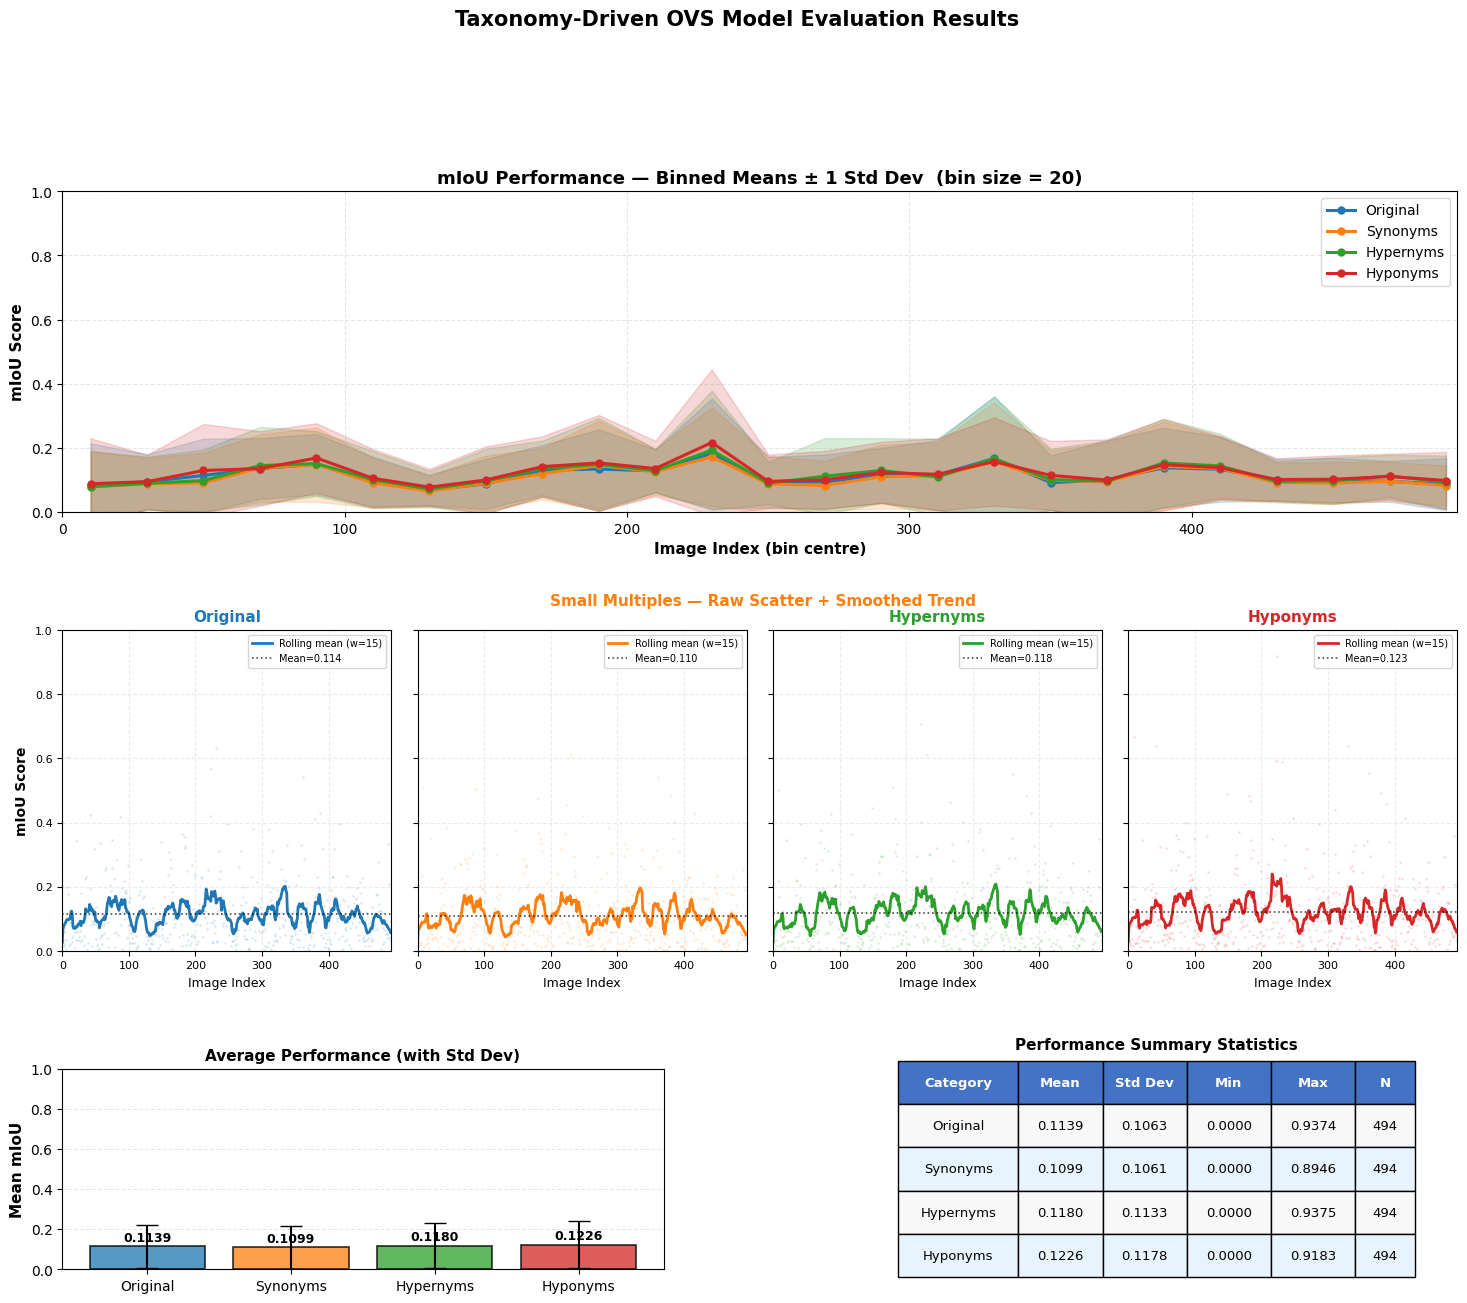


                        SEGMENTATION PERFORMANCE SUMMARY                        

Total images evaluated: 494


ORIGINAL
  Mean mIoU : 0.1139
  Std Dev   : 0.1063
  Min       : 0.0000
  Max       : 0.9374

SYNONYMS
  Mean mIoU : 0.1099
  Std Dev   : 0.1061
  Min       : 0.0000
  Max       : 0.8946

HYPERNYMS
  Mean mIoU : 0.1180
  Std Dev   : 0.1133
  Min       : 0.0000
  Max       : 0.9375

HYPONYMS
  Mean mIoU : 0.1226
  Std Dev   : 0.1178
  Min       : 0.0000
  Max       : 0.9183

Best performing:          Hyponyms (mean: 0.1226)


In [46]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

colors = {
    'Original':  '#1f77b4',
    'Synonyms':  '#ff7f0e',
    'Hypernyms': '#2ca02c',
    'Hyponyms':  '#d62728'
}
CAT_TYPES = ['Original', 'Synonyms', 'Hypernyms', 'Hyponyms']
BIN_SIZE   = 20   # images per bin for the binned-mean + ribbon chart

# ── summary stats ────────────────────────────────────────────────────────────
summary_stats = {}
for cat_type, results_list in results.items():
    mious = np.array([r['miou'] for r in results_list])
    summary_stats[cat_type] = {
        'mious': mious,
        'mean':  np.mean(mious),
        'std':   np.std(mious),
        'min':   np.min(mious),
        'max':   np.max(mious),
        'count': len(mious),
    }

n_images = summary_stats['Original']['count']

# ── binned means + std ribbons ────────────────────────────────────────────────
def compute_bins(mious, bin_size):
    """Return bin centres, bin means, bin stds."""
    n = len(mious)
    edges   = np.arange(0, n, bin_size)
    centres = edges + bin_size / 2
    means   = [np.mean(mious[s:s + bin_size]) for s in edges]
    stds    = [np.std(mious[s:s + bin_size])  for s in edges]
    return centres, np.array(means), np.array(stds)

# ── rolling mean helper ───────────────────────────────────────────────────────
def rolling_mean(arr, w=15):
    return np.convolve(arr, np.ones(w) / w, mode='same')

# ── figure layout ─────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(18, 14))
gs_outer = gridspec.GridSpec(3, 2, figure=fig, hspace=0.42, wspace=0.32,
                              height_ratios=[1.6, 1.6, 1])

# ── [TOP]  Binned mean + ribbon (all 4 on one axes) ──────────────────────────
ax_top = fig.add_subplot(gs_outer[0, :])

for cat in CAT_TYPES:
    mious = summary_stats[cat]['mious']
    centres, bmeans, bstds = compute_bins(mious, BIN_SIZE)
    c = colors[cat]
    ax_top.plot(centres, bmeans, marker='o', ms=5, lw=2.2, label=cat, color=c)
    ax_top.fill_between(centres, bmeans - bstds, bmeans + bstds,
                        alpha=0.18, color=c)

ax_top.set_xlabel('Image Index (bin centre)', fontsize=11, fontweight='bold')
ax_top.set_ylabel('mIoU Score', fontsize=11, fontweight='bold')
ax_top.set_title(
    f'mIoU Performance — Binned Means ± 1 Std Dev  (bin size = {BIN_SIZE})',
    fontsize=13, fontweight='bold')
ax_top.legend(fontsize=10, loc='upper right')
ax_top.set_ylim(0, 1)
ax_top.set_xlim(0, n_images)
ax_top.grid(True, alpha=0.3, linestyle='--')

# ── [MID]  Small multiples — one panel per category ──────────────────────────
gs_mid = gridspec.GridSpecFromSubplotSpec(1, 4, subplot_spec=gs_outer[1, :],
                                          wspace=0.08)
axes_sm = [fig.add_subplot(gs_mid[i]) for i in range(4)]

for idx, cat in enumerate(CAT_TYPES):
    ax = axes_sm[idx]
    mious  = summary_stats[cat]['mious']
    x      = np.arange(n_images)
    smooth = rolling_mean(mious, w=15)
    c      = colors[cat]

    ax.scatter(x, mious, s=3, alpha=0.18, color=c, linewidths=0)
    ax.plot(x, smooth, lw=2, color=c, label='Rolling mean (w=15)')

    ax.axhline(summary_stats[cat]['mean'], color='black',
               lw=1.2, ls=':', alpha=0.7, label=f"Mean={summary_stats[cat]['mean']:.3f}")

    ax.set_title(cat, fontsize=11, fontweight='bold', color=c)
    ax.set_ylim(0, 1)
    ax.set_xlim(0, n_images)
    ax.grid(True, alpha=0.25, linestyle='--')
    ax.tick_params(labelsize=8)
    ax.legend(fontsize=7, loc='upper right')

    if idx == 0:
        ax.set_ylabel('mIoU Score', fontsize=10, fontweight='bold')
    else:
        ax.set_yticklabels([])

    ax.set_xlabel('Image Index', fontsize=9)

axes_sm[1].set_title('Small Multiples — Raw Scatter + Smoothed Trend',
                      fontsize=11, fontweight='bold', pad=18, x=1.05)

# ── [BOT-LEFT]  Bar chart with std dev caps ───────────────────────────────────
ax_bar = fig.add_subplot(gs_outer[2, 0])

means = [summary_stats[ct]['mean'] for ct in CAT_TYPES]
stds  = [summary_stats[ct]['std']  for ct in CAT_TYPES]
bars  = ax_bar.bar(CAT_TYPES, means, yerr=stds, capsize=8,
                   color=[colors[ct] for ct in CAT_TYPES],
                   alpha=0.75, edgecolor='black', linewidth=1.3)

for bar, mean in zip(bars, means):
    ax_bar.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                f'{mean:.4f}', ha='center', va='bottom',
                fontweight='bold', fontsize=9)

ax_bar.set_ylabel('Mean mIoU', fontsize=11, fontweight='bold')
ax_bar.set_title('Average Performance (with Std Dev)', fontsize=11, fontweight='bold')
ax_bar.set_ylim(0, 1)
ax_bar.grid(True, alpha=0.3, axis='y', linestyle='--')

# ── [BOT-RIGHT]  Summary table ───────────────────────────────────────────────
ax_tbl = fig.add_subplot(gs_outer[2, 1])
ax_tbl.axis('off')

header = ['Category', 'Mean', 'Std Dev', 'Min', 'Max', 'N']
rows   = []
for ct in CAT_TYPES:
    s = summary_stats[ct]
    rows.append([ct,
                 f"{s['mean']:.4f}", f"{s['std']:.4f}",
                 f"{s['min']:.4f}",  f"{s['max']:.4f}",
                 str(s['count'])])

tbl = ax_tbl.table(cellText=rows, colLabels=header,
                   cellLoc='center', loc='center',
                   colWidths=[0.20, 0.14, 0.14, 0.14, 0.14, 0.10])
tbl.auto_set_font_size(False)
tbl.set_fontsize(9.5)
tbl.scale(1, 2.6)

for j in range(len(header)):
    tbl[(0, j)].set_facecolor('#4472C4')
    tbl[(0, j)].set_text_props(weight='bold', color='white')

for i, ct in enumerate(CAT_TYPES, start=1):
    for j in range(len(header)):
        tbl[(i, j)].set_facecolor('#E8F4FD' if i % 2 == 0 else '#F8F8F8')

ax_tbl.set_title('Performance Summary Statistics', fontsize=11,
                  fontweight='bold', pad=14)

# ── super-title ───────────────────────────────────────────────────────────────
plt.suptitle('Taxonomy-Driven OVS Model Evaluation Results',
             fontsize=15, fontweight='bold', y=1.01)

plt.savefig('taxonomy_ovs_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

# ── console summary ───────────────────────────────────────────────────────────
print("\n" + "=" * 80)
print("SEGMENTATION PERFORMANCE SUMMARY".center(80))
print("=" * 80)
print(f"\nTotal images evaluated: {summary_stats['Original']['count']}\n")

for ct in CAT_TYPES:
    s = summary_stats[ct]
    print(f"\n{ct.upper()}")
    print(f"  Mean mIoU : {s['mean']:.4f}")
    print(f"  Std Dev   : {s['std']:.4f}")
    print(f"  Min       : {s['min']:.4f}")
    print(f"  Max       : {s['max']:.4f}")

best = max(summary_stats.items(), key=lambda x: x[1]['mean'])
print(f"\n{'Best performing:'.ljust(25)} {best[0]} (mean: {best[1]['mean']:.4f})")
print("=" * 80)

In [47]:
coco_cat_id_to_name = {cat['id']: cat['name'] for cat in coco.loadCats(coco.getCatIds())}
coco_cat_id_to_name_smple = {}
for res in results['Original']:
    ious = res['ious']
    for  class_id in ious.keys():
        coco_cat_id_to_name_smple[class_id] = coco_cat_id_to_name.get(int(class_id), 'Unknown')
print(coco_cat_id_to_name_smple)

{79: 'oven', 51: 'bowl', 56: 'broccoli', 49: 'knife', 81: 'sink', 67: 'dining table', 1: 'person', 44: 'bottle', 47: 'cup', 57: 'carrot', 50: 'spoon', 52: 'banana', 64: 'potted plant', 82: 'refrigerator', 62: 'chair', 55: 'orange', 10: 'traffic light', 31: 'handbag', 28: 'umbrella', 2: 'bicycle', 41: 'skateboard', 8: 'truck', 3: 'car', 70: 'toilet', 4: 'motorcycle', 16: 'bird', 84: 'book', 76: 'keyboard', 72: 'tv', 86: 'vase', 63: 'couch', 33: 'suitcase', 5: 'airplane', 25: 'giraffe', 21: 'cow', 9: 'boat', 15: 'bench', 20: 'sheep', 6: 'bus', 27: 'backpack', 7: 'train', 13: 'stop sign', 18: 'dog', 17: 'cat', 73: 'laptop', 32: 'tie', 22: 'elephant', 85: 'clock', 34: 'frisbee', 23: 'bear', 24: 'zebra', 19: 'horse', 35: 'skis', 40: 'baseball glove', 37: 'sports ball', 60: 'donut', 54: 'sandwich', 61: 'cake', 42: 'surfboard', 65: 'bed', 59: 'pizza', 43: 'tennis racket', 90: 'toothbrush', 75: 'remote', 53: 'apple', 38: 'kite', 36: 'snowboard', 39: 'baseball bat', 11: 'fire hydrant', 74: 'mou

In [48]:
VARIANTS = ['Original', 'Synonyms', 'Hypernyms', 'Hyponyms']
class_variant_ious = defaultdict(lambda: defaultdict(list))

for variant in VARIANTS:
    for entry in results[variant]:
        img_id = entry['img_id']

        # Find the matching Original entry to get canonical class names
        orig_entry = next(
            (e for e in results['Original'] if e['img_id'] == img_id), None
        )
        if orig_entry is None:
            continue

        orig_classes = orig_entry['categories']   # e.g. ['car', 'person']
        ious         = entry['ious']              # parallel IoU list

        for cls_name, (cat_id, iou_val) in zip(orig_classes, ious.items()):
            class_variant_ious[cls_name][variant].append(iou_val)
print(class_variant_ious['bottle'])

defaultdict(<class 'list'>, {'Original': [0.005679031269160024, 0.006911492027631105, 0.22129403596783948, 0.053334946793625826, 0.001912872053614428, 0.0, 0.0012315375534020163, 0.00012282537670543035, 0.020070523703800445, 0.01087635788270021, 0.004699259850971679, 0.02453012653641976, 0.004733659738176847, 0.04239203499303452, 0.05896561894486114, 0.0020099309580802784, 0.03359325877718603, 0.00829124013951871, 0.0006472599883226291, 0.014583020805686657, 0.002307064028768624, 0.00724042233212918, 0.007360178481594086, 0.01537231916877581, 0.009479485506882768, 0.036338532265778066, 0.0042407841885638035, 0.0, 0.006197741528065697, 0.0008530843829222164], 'Synonyms': [0.0070864673338720706, 0.007767639013593368, 0.31785074002910274, 0.05895218439509059, 0.0024352370201866824, 0.0001256331625864442, 0.0015441712858687028, 0.0, 0.010253471456909852, 0.012942474813200376, 0.004845600876270338, 0.02335439194054335, 0.005047425596472936, 0.05970855081094335, 0.06455548461347638, 0.002937

In [49]:
def lss_per_class(variant_iou_dict, variants=VARIANTS):
    """
    LSS(M, c) = std-dev of mean-IoU values across variants.

    variant_iou_dict : {variant: [iou, ...]}
    Returns (lss_value, mu_per_variant, mu_M_c)
    """
    # μ_{M,c,v} = mean IoU for this class under variant v
    available = {v: variant_iou_dict[v] for v in variants
                 if v in variant_iou_dict and len(variant_iou_dict[v]) > 0}
    
    if len(available) < 2:       # can't compute meaningful spread with <2 variants
        return None, {}, None
    
    mu_per_variant = {v: np.mean(ious) for v, ious in available.items()}
    mu_values      = np.array(list(mu_per_variant.values()))
    mu_M_c         = np.mean(mu_values)
    lss_c          = np.sqrt(np.mean((mu_values - mu_M_c) ** 2))

    return lss_c, mu_per_variant, mu_M_c

# Compute LSS for every class that appears in the results
lss_per_class_results = {}

for cls_name, variant_dict in class_variant_ious.items():
    # Only score classes that have data in ALL variants
    if all(len(variant_dict[v]) > 0 for v in VARIANTS):
        lss_c, mu_per_v, mu_c = lss_per_class(variant_dict)
        lss_per_class_results[cls_name] = {
            'LSS':            lss_c,
            'mu_M_c':         mu_c,
            'mu_per_variant': mu_per_v,
            'n_images':       len(variant_dict['Original']),
        }

# LSS(M) = 1/|C| * Σ_c LSS(M, c)
all_lss_values = [v['LSS'] for v in lss_per_class_results.values()]
LSS_M = np.mean(all_lss_values) if all_lss_values else 0.0

In [50]:

print("\n" + "=" * 80)
print("LINGUISTIC SENSITIVITY SCORE (LSS) RESULTS".center(80))
print("=" * 80)
print(f"\n  Model-level LSS(M) = {LSS_M:.4f}")
print(f"  (averaged over {len(lss_per_class_results)} classes)\n")
print(f"  Interpretation: on average, the model's per-class mIoU varies by")
print(f"  ±{LSS_M:.4f} across linguistic variants (lower = more robust)\n")

# Sort classes by LSS descending (most sensitive first)
sorted_classes = sorted(lss_per_class_results.items(),
                        key=lambda x: x[1]['LSS'], reverse=True)

header = f"{'Class':<20} {'LSS':>7}  {'μ(all)':>7}  " + \
         "  ".join(f"{v[:4]:>7}" for v in VARIANTS) + "  'N':>5"
print(header)
print("-" * len(header))

for cls_name, stats in sorted_classes:
    variant_means = "  ".join(
        f"{stats['mu_per_variant'][v]:>7.4f}" for v in VARIANTS
    )
    print(f"{cls_name:<20} {stats['LSS']:>7.4f}  {stats['mu_M_c']:>7.4f}  "
          f"{variant_means}  {stats['n_images']:>5}")

print("=" * 80)


                   LINGUISTIC SENSITIVITY SCORE (LSS) RESULTS                   

  Model-level LSS(M) = 0.0071
  (averaged over 79 classes)

  Interpretation: on average, the model's per-class mIoU varies by
  ±0.0071 across linguistic variants (lower = more robust)

Class                    LSS   μ(all)     Orig     Syno     Hype     Hypo  'N':>5
---------------------------------------------------------------------------------
elephant              0.0403   0.1256   0.1186   0.0625   0.1586   0.1627      9
pizza                 0.0262   0.2345   0.2424   0.1969   0.2291   0.2697     21
zebra                 0.0258   0.0631   0.0599   0.0679   0.0260   0.0986     11
sheep                 0.0243   0.1316   0.1282   0.1081   0.1718   0.1183     13
hot dog               0.0226   0.2080   0.2213   0.2333   0.1731   0.2044      3
cat                   0.0218   0.1038   0.1048   0.0866   0.1390   0.0847     22
broccoli              0.0199   0.0892   0.0927   0.1082   0.0997   0.0560     14

In [51]:
print(results['Original'][:5])

[{'img_id': 397133, 'miou': 0.03509675119414481, 'ious': {79: 0.07160159165525737, 51: 0.014292328687006532, 56: 0.0, 49: 0.0005071576586749714, 81: 0.009616232906925452, 67: 0.20229827374294548, 1: 0.07604931300583474, 44: 0.005679031269160024, 47: 0.005599200818913953, 57: 0.0, 50: 0.0004211333908743313}, 'categories': ['oven', 'bowl', 'broccoli', 'knife', 'sink', 'dining table', 'person', 'bottle', 'cup', 'carrot', 'spoon']}, {'img_id': 37777, 'miou': 0.0301956370299782, 'ious': {79: 0.045770274038583414, 52: 0.004996852881861039, 64: 0.0010554941575293985, 82: 0.07963919129082427, 62: 0.019359670473694066, 55: 0.011570626646809485, 81: 0.0007277837729314628, 67: 0.07844520297759248}, 'categories': ['oven', 'banana', 'potted plant', 'refrigerator', 'chair', 'orange', 'sink', 'dining table']}, {'img_id': 252219, 'miou': 0.022350236630847314, 'ious': {10: 0.012807121852452958, 31: 0.0017891300830803491, 1: 0.09460639074709798, 28: 0.0019605127166952576, 47: 0.0005880277549100317}, 'ca

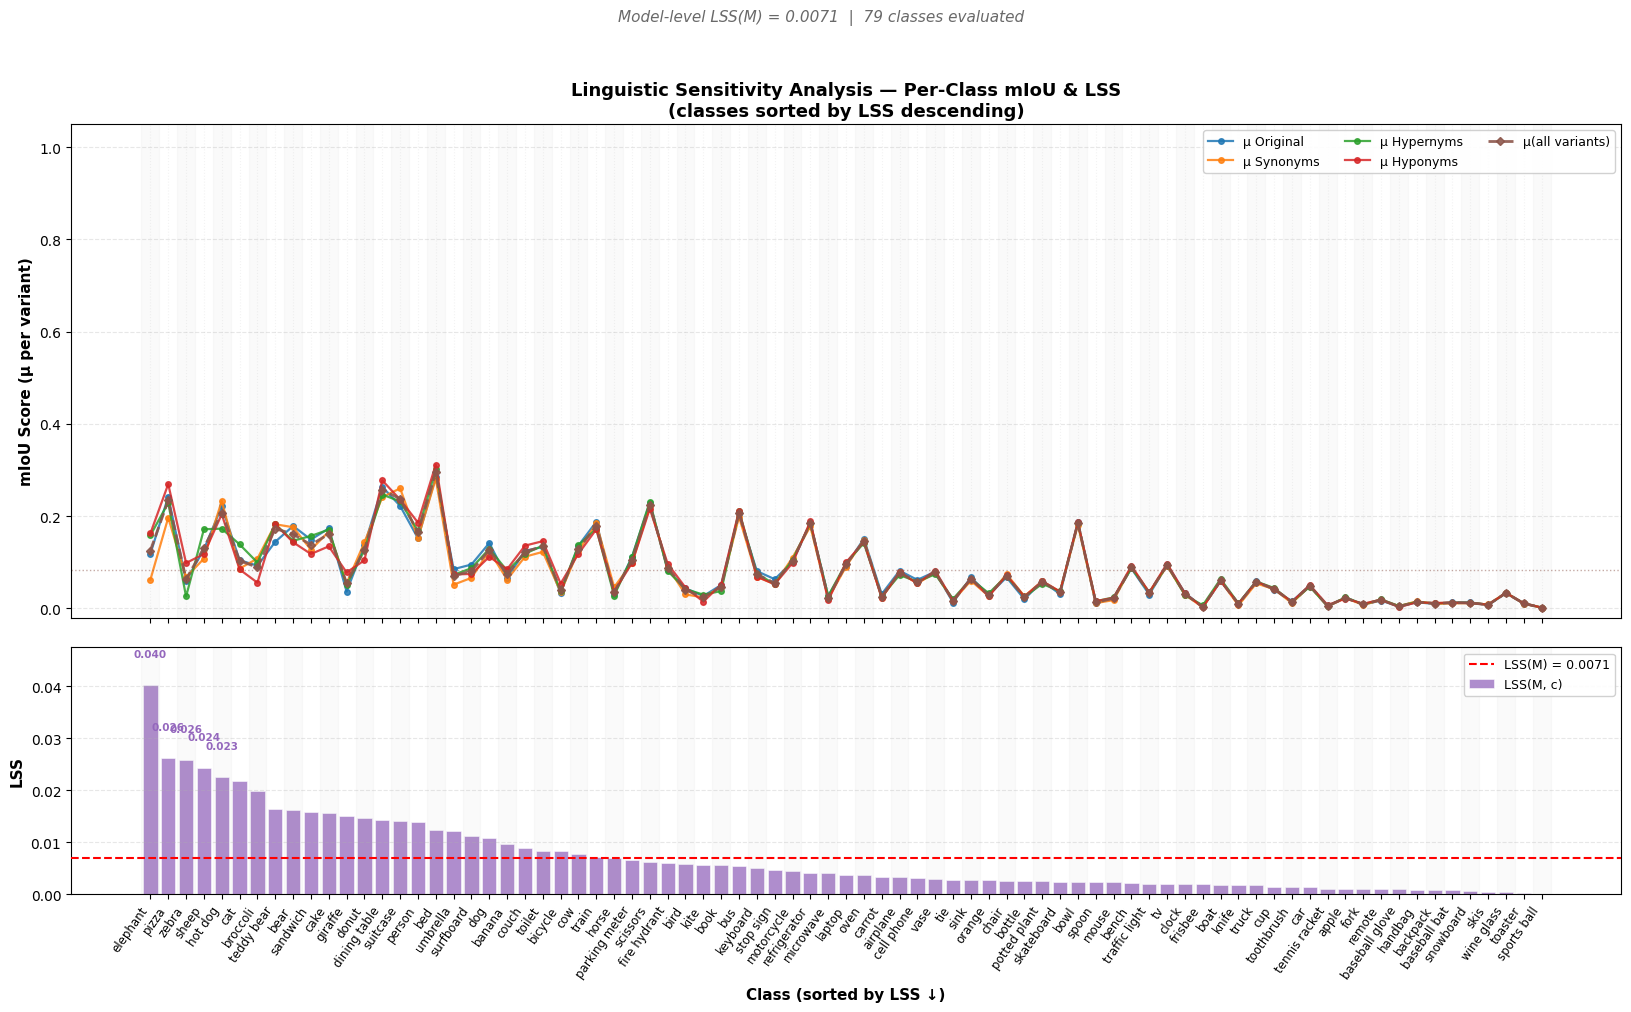

In [52]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

# ── Rebuild sorted data from lss_per_class_results ───────────────────────────
sorted_classes = sorted(
    lss_per_class_results.items(),
    key=lambda x: x[1]['LSS'], reverse=True
)

cls_names   = [c[0] for c in sorted_classes]
lss_vals    = np.array([c[1]['LSS']    for c in sorted_classes])
mu_vals     = np.array([c[1]['mu_M_c'] for c in sorted_classes])
x           = np.arange(len(cls_names))

variant_vals = {
    v: np.array([c[1]['mu_per_variant'][v] for c in sorted_classes])
    for v in VARIANTS
}

# ── Style config ──────────────────────────────────────────────────────────────
VARIANT_COLORS = {
    'Original':  '#1f77b4',
    'Synonyms':  '#ff7f0e',
    'Hypernyms': '#2ca02c',
    'Hyponyms':  '#d62728',
}
LSS_COLOR = '#9467bd'
MU_COLOR  = '#8c564b'

# ── Figure: 2 stacked panels sharing x-axis ──────────────────────────────────
fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(20, 10), sharex=True,
    gridspec_kw={'height_ratios': [2, 1], 'hspace': 0.08}
)

# ── TOP panel — per-variant μ + overall μ ─────────────────────────────────────
for v in VARIANTS:
    ax1.plot(x, variant_vals[v], marker='o', ms=4, lw=1.6,
             label=f'μ {v}', color=VARIANT_COLORS[v], alpha=0.85)

ax1.plot(x, mu_vals, marker='D', ms=4, lw=2, ls='--',
         label='μ(all variants)', color=MU_COLOR, alpha=0.9, zorder=5)

ax1.axhline(np.mean(mu_vals), color=MU_COLOR, lw=1, ls=':', alpha=0.5)

ax1.set_ylabel('mIoU Score (μ per variant)', fontsize=11, fontweight='bold')
ax1.set_title('Linguistic Sensitivity Analysis — Per-Class mIoU & LSS\n'
              '(classes sorted by LSS descending)',
              fontsize=13, fontweight='bold')
ax1.set_ylim(-0.02, 1.05)
ax1.legend(fontsize=9, loc='upper right', ncol=3, framealpha=0.9)
ax1.grid(True, axis='y', alpha=0.3, linestyle='--')
ax1.grid(True, axis='x', alpha=0.15, linestyle=':')

# shade alternating class columns for readability
for i in range(0, len(cls_names), 2):
    ax1.axvspan(i - 0.5, i + 0.5, color='grey', alpha=0.04)

# ── BOTTOM panel — LSS per class ─────────────────────────────────────────────
ax2.bar(x, lss_vals, color=LSS_COLOR, alpha=0.75, edgecolor='white',
        linewidth=0.5, label='LSS(M, c)')
ax2.axhline(LSS_M, color='red', lw=1.5, ls='--',
            label=f'LSS(M) = {LSS_M:.4f}', zorder=5)

ax2.set_ylabel('LSS', fontsize=11, fontweight='bold')
ax2.set_ylim(0, max(lss_vals) * 1.18)
ax2.legend(fontsize=9, loc='upper right', framealpha=0.9)
ax2.grid(True, axis='y', alpha=0.3, linestyle='--')

for i in range(0, len(cls_names), 2):
    ax2.axvspan(i - 0.5, i + 0.5, color='grey', alpha=0.04)

# ── Shared x-axis labels ──────────────────────────────────────────────────────
ax2.set_xticks(x)
ax2.set_xticklabels(cls_names, rotation=55, ha='right', fontsize=8.5)
ax2.set_xlabel('Class (sorted by LSS ↓)', fontsize=11, fontweight='bold')

# ── Annotate top-5 most sensitive classes ────────────────────────────────────
for i in range(min(5, len(cls_names))):
    ax2.text(i, lss_vals[i] + 0.005, f'{lss_vals[i]:.3f}',
             ha='center', va='bottom', fontsize=7.5,
             fontweight='bold', color=LSS_COLOR)

# ── Super-title with model LSS ────────────────────────────────────────────────
fig.text(0.5, 0.995,
         f'Model-level LSS(M) = {LSS_M:.4f}  |  {len(cls_names)} classes evaluated',
         ha='center', va='top', fontsize=11, color='dimgray', style='italic')

plt.savefig('lss_line_chart.png', dpi=150, bbox_inches='tight')
plt.show()